In [2]:
import jaxley

Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.


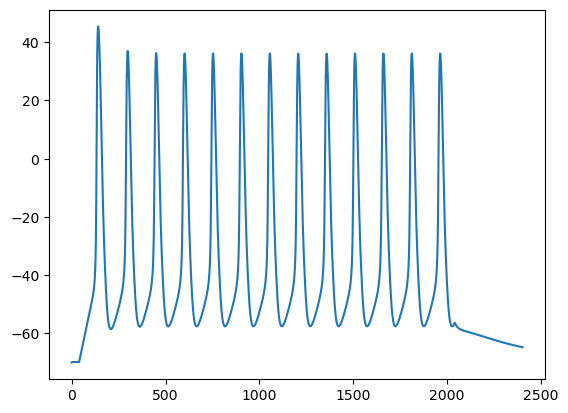

In [90]:
import matplotlib.pyplot as plt
from jax import config
import jax.numpy as jnp

import jaxley as jx
from jaxley.channels import Na, K, Leak,  Km, CaL, CaT

config.update("jax_platform_name", "gpu")  # Or "gpu" / "tpu".

cell = jx.Cell()  # Define cell.
cell.nodes.radius = 10.0  # typical soma radius in μm
cell.nodes.length = 10.0  # typical soma length in μm
cell.insert(Na())
cell.insert(K())
cell.insert(Leak())
cell.insert(Km())
cell.insert(CaL())
cell.insert(CaT())


current = jx.step_current(i_delay=1.0, i_dur=50.0, i_amp=0.08, delta_t=0.025, t_max=60.0)
cell.stimulate(current)  # Stimulate with step current.
cell.record("v")  # Record voltage.

v = jx.integrate(cell)  # Run simulation.
plt.plot(v.T)  # Plot voltage trace.

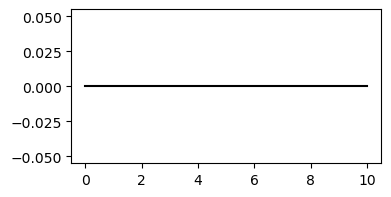

In [91]:
cell.compute_xyz()  # Only needed for visualization.

fig, ax = plt.subplots(1, 1, figsize=(4, 2))
_ = cell.vis(ax=ax, color="k")

In [161]:
parents = jnp.asarray([-1, 0, 0, 1, 1])
branch = jx.Branch(ncomp=2)
cell = jx.Cell(branch, parents=parents)

In [162]:
parents = jnp.asarray([-1, 0, 0, 1, 1])
cell = jx.Cell(branch, parents=parents)

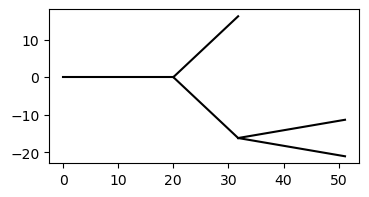

In [163]:
cell.compute_xyz()  # Only needed for visualization.

fig, ax = plt.subplots(1, 1, figsize=(4, 2))
_ = cell.vis(ax=ax, color="k")

In [164]:

cell.delete_stimuli()

cell.set("radius", 10)
cell.set("length", 10)

cell.insert(Leak())
cell.branch(0).insert(Na())
cell.branch(0).insert(K())
# cell.branch(1).set("axial_resistivity", 5000.0)


# cell.branch(0).set("K_gK", 0.01)  # modify potassium conductance.
# cell.set("v", -65.0)  # modify initial voltage.

current = jx.step_current(i_delay=1.0, i_dur=20.0, i_amp=0.08,delta_t=0.0025,t_max=40.)
cell.branch(0).loc(0.).stimulate(current)  # Stimulate with step current.

Added 1 external_states. See `.externals` for details.


In [165]:
cell.delete_recordings()

cell.branch(0).loc(0.).record("v")  # Record voltage.
cell.branch(3).loc(1.).record("v")  # Record voltage.


Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.


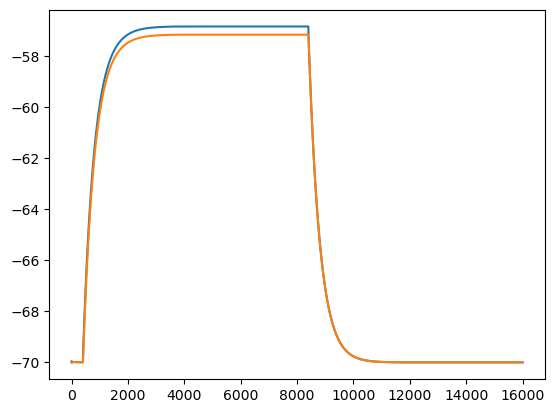

In [166]:
v = jx.integrate(cell)  # Run simulation.
plt.plot(v.T)  # Plot voltage trace.

In [222]:
from jax import config
config.update("jax_enable_x64", True)
config.update("jax_platform_name", "cpu")

import matplotlib.pyplot as plt
import numpy as np
import jax.numpy as jnp
from jax import jit

import jaxley as jx
from jaxley.channels import Na, K, Leak
from jaxley.synapses import IonotropicSynapse
from jaxley.connect import fully_connect, connect

In [223]:
comp = jx.Compartment()
branch = jx.Branch(comp, ncomp=4)
cell = jx.Cell(branch, parents=[-1, 0, 0, 1, 1, 2, 2])

num_cells = 11
net = jx.Network([cell for _ in range(num_cells)])

In [224]:
pre = net.cell(range(10))
post = net.cell(10)
fully_connect(pre, post, IonotropicSynapse())

In [225]:
pre = net.cell(10).branch(0).loc(0.0)
for i in range(1,5):
    post = net.cell(i).branch(5).loc(1.0)
    connect(pre, post, IonotropicSynapse())

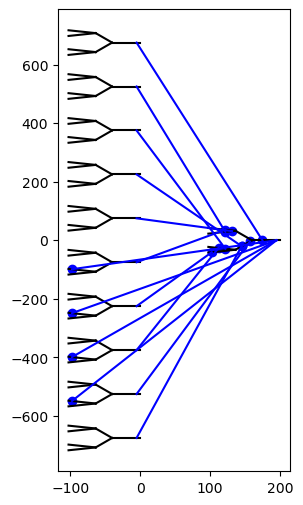

In [227]:
net.compute_xyz()
net.rotate(180)
net.arrange_in_layers(layers=[10, 1], within_layer_offset=150, between_layer_offset=200)

fig, ax = plt.subplots(1, 1, figsize=(3, 6))
_ = net.vis(ax=ax, detail="full")

In [246]:
# Stimulus.
i_delay = 3.0  # ms
i_amp = 0.05  # nA
i_dur = 500.0  # ms

# Duration and step size.
dt = 0.025  # ms
t_max = 1000.0  # ms

time_vec = jnp.arange(0.0, t_max + dt, dt)

In [247]:
net.insert(Na())
net.insert(K())
net.insert(Leak())

In [248]:
net.set("IonotropicSynapse_gS", 0.0001)  # nS

In [249]:
current = jx.step_current(i_delay, i_dur, i_amp, dt, t_max)
net.delete_stimuli()
for stim_ind in range(10):
    net.cell(stim_ind).branch(0).loc(0.0).stimulate(current)

net.delete_recordings()

for i in range(1,11):
    net.cell(i).branch(0).loc(0.0).record()

Added 1 external_states. See `.externals` for details.
Added 1 external_states. See `.externals` for details.
Added 1 external_states. See `.externals` for details.
Added 1 external_states. See `.externals` for details.
Added 1 external_states. See `.externals` for details.
Added 1 external_states. See `.externals` for details.
Added 1 external_states. See `.externals` for details.
Added 1 external_states. See `.externals` for details.
Added 1 external_states. See `.externals` for details.
Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for 

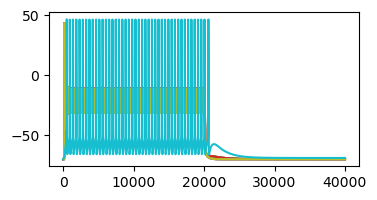

In [250]:
s = jx.integrate(net, delta_t=dt)

fig, ax = plt.subplots(1, 1, figsize=(4, 2))
_ = ax.plot(s.T)